In [22]:
# Model Building

#Goal: Train, evaluate and compare ML models to predict wildfire insurance risk.

### Models:
#1. Random Forest
#2. XGBoost
#3. Gradient Boosting

### Evaluation Metrics:
#- Accuracy
#- Precision, Recall, F1-Score
#- Confusion Matrix
#- Feature Importance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import joblib
import os

# Load all 4 files
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f" Data loaded!")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\ny_train distribution:")
print(y_train.value_counts())

 Data loaded!
X_train : (318819, 130)
X_test  : (43558, 130)

y_train distribution:
risk_level
Low       106273
High      106273
Medium    106273
Name: count, dtype: int64


In [3]:
# Models need numbers not text for y
# High=2, Medium=1, Low=0  (3 classes after data cleaning step)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f" Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"   {cls} → {i}")

 Label encoding:
   High → 0
   Low → 1
   Medium → 2


In [4]:
#Models

In [5]:
#Random Forest

In [6]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train_enc)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test_enc, y_pred_rf)

print(f" Random Forest complete!")
print(f"Accuracy: {acc_rf*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test_enc, y_pred_rf, target_names=le.classes_))

Training Random Forest...
 Random Forest complete!
Accuracy: 94.58%

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.96      0.96     26568
         Low       0.93      0.94      0.94     16342
      Medium       0.56      0.30      0.39       648

    accuracy                           0.95     43558
   macro avg       0.82      0.74      0.76     43558
weighted avg       0.94      0.95      0.94     43558



In [7]:
#XGBoost

In [8]:
# XGBoost doesn't allow [ ] < in column names
# Cleaning column names for all models (consistent across pipeline)

import re

clean_cols = [re.sub(r'[\[\]<]', '', col) for col in X_train.columns]

X_train.columns = clean_cols
X_test.columns  = clean_cols

print(" Column names cleaned")
print(f"Sample columns: {list(X_train.columns[:5])}")

 Column names cleaned
Sample columns: ['year_built', 'assessed_value', 'latitude', 'longitude', 'fire_year']


In [9]:
print("Training XGBoost...")

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=1
)
xgb.fit(X_train, y_train_enc)

y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test_enc, y_pred_xgb)

print(f" XGBoost complete!")
print(f"Accuracy: {acc_xgb*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

Training XGBoost...
 XGBoost complete!
Accuracy: 93.11%

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.95      0.95     26568
         Low       0.92      0.93      0.92     16342
      Medium       0.30      0.26      0.28       648

    accuracy                           0.93     43558
   macro avg       0.72      0.71      0.72     43558
weighted avg       0.93      0.93      0.93     43558



In [10]:
# Gradient Boosting

In [11]:
print("Training Gradient Boosting...")

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train_enc)

y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test_enc, y_pred_gb)

print(f" Gradient Boosting complete!")
print(f"Accuracy: {acc_gb*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test_enc, y_pred_gb, target_names=le.classes_))

Training Gradient Boosting...
 Gradient Boosting complete!
Accuracy: 91.06%

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.91      0.93     26568
         Low       0.88      0.93      0.91     16342
      Medium       0.20      0.30      0.24       648

    accuracy                           0.91     43558
   macro avg       0.68      0.71      0.69     43558
weighted avg       0.92      0.91      0.91     43558



In [12]:
#Model Comparison

MODEL COMPARISON — Insurance Risk Prediction
            Model  Accuracy
    Random Forest 94.577345
          XGBoost 93.110336
Gradient Boosting 91.064787


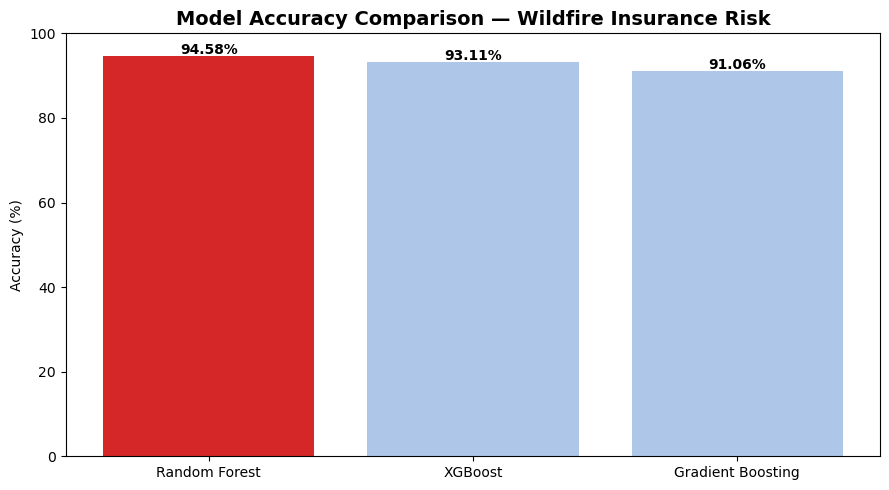


 Best Model: Random Forest (94.58%)


In [13]:
# Summary table
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Gradient Boosting'],
    'Accuracy': [acc_rf*100, acc_xgb*100, acc_gb*100]
}).sort_values('Accuracy', ascending=False)

print("=" * 45)
print("MODEL COMPARISON — Insurance Risk Prediction")
print("=" * 45)
print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 5))
colors = ['#d62728' if acc == results['Accuracy'].max() else '#aec7e8'
          for acc in results['Accuracy']]
plt.bar(results['Model'], results['Accuracy'], color=colors)
plt.title('Model Accuracy Comparison — Wildfire Insurance Risk', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, (model, acc) in enumerate(zip(results['Model'], results['Accuracy'])):
    plt.text(i, acc + 0.5, f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = results.iloc[0]['Model']
print(f"\n Best Model: {best_model_name} ({results.iloc[0]['Accuracy']:.2f}%)")

In [14]:
#Confusion Matrix — Best Model

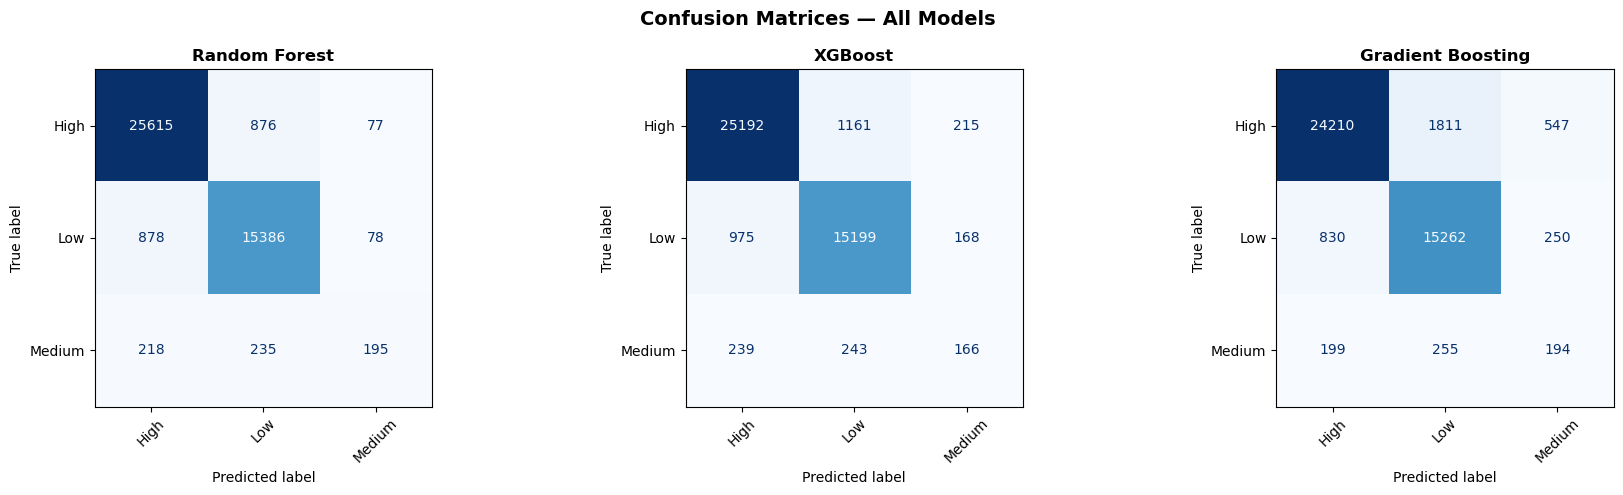

In [15]:
best_preds = {
    'Random Forest':      y_pred_rf,
    'XGBoost':            y_pred_xgb,
    'Gradient Boosting':  y_pred_gb
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, best_preds.items()):
    cm = confusion_matrix(y_test_enc, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
## Feature Importance — Random Forest

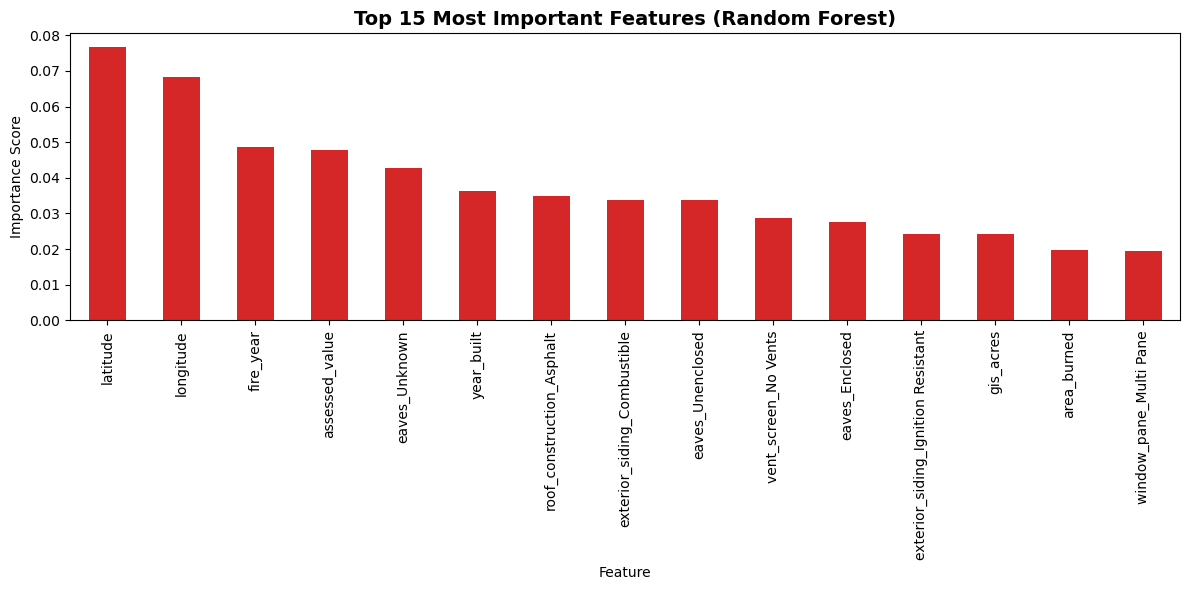

Top 15 features:
latitude                              0.076714
longitude                             0.068295
fire_year                             0.048757
assessed_value                        0.047744
eaves_Unknown                         0.042813
year_built                            0.036214
roof_construction_Asphalt             0.034924
exterior_siding_Combustible           0.033898
eaves_Unenclosed                      0.033808
vent_screen_No Vents                  0.028792
eaves_Enclosed                        0.027680
exterior_siding_Ignition Resistant    0.024269
gis_acres                             0.024210
area_burned                           0.019622
window_pane_Multi Pane                0.019465
dtype: float64


In [20]:
# Top 15 features from Random Forest
feat_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
feat_importance.plot(kind='bar', color='#d62728')
plt.title('Top 15 Most Important Features (Random Forest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../outputs/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 features:")
print(feat_importance)

In [21]:
# Save all 3 models
os.makedirs('../models', exist_ok=True)

joblib.dump(rf,  '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost.pkl')
joblib.dump(gb,  '../models/gradient_boosting.pkl')
joblib.dump(le,  '../models/label_encoder.pkl')

print(" All models saved to models/")
print("   random_forest.pkl")
print("   xgboost.pkl")
print("   gradient_boosting.pkl")
print("   label_encoder.pkl")
print(f"\n Best model: {best_model_name}")

 All models saved to models/
   random_forest.pkl
   xgboost.pkl
   gradient_boosting.pkl
   label_encoder.pkl

 Best model: Random Forest
